# 03. 収束・エネルギー・Parseval

**この章のゴール**: フーリエ級数が「どの意味で」収束するのかを区別し、
エネルギー保存則 **Parseval の等式** を確かめ、**滑らかさが係数の減衰速度として現れる**
ことを観察する。

## Big Picture

部分和 $S_N f$ が元の $f$ に「近づく」と言うとき、近づき方には種類があります。

- **平均二乗(L²)収束**: 誤差のエネルギー $\|f-S_Nf\|_2^2 \to 0$
- **各点収束**: 各 $x$ で $S_Nf(x)\to f(x)$(跳びの点では平均値)
- **一様(sup)収束**: 最大誤差 $\max_x|f-S_Nf|\to 0$(不連続があると **成り立たない**)

そして **Parseval**: 時間領域のエネルギーと周波数領域のエネルギーは等しい。

## Problem

矩形波の部分和は、倍音を増やせば本当に矩形波に「収束」するのでしょうか。
答えは「平均二乗では Yes、最大誤差では No(Gibbs)」。この食い違いを数値で見ます。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## Definition — ノルムと Parseval

エネルギー(L² ノルムの 2 乗):

$$ \|f\|_2^2 = \int_{-\pi}^{\pi} |f(x)|^2\,dx. $$

**Parseval の等式**(複素係数版):

$$ \frac{1}{2\pi}\int_{-\pi}^{\pi}|f(x)|^2\,dx = \sum_{n=-\infty}^{\infty} |c_n|^2. $$

離散版(DFT)では

$$ \sum_{n=0}^{N-1}|x_n|^2 = \frac{1}{N}\sum_{k=0}^{N-1}|X_k|^2. $$

「エネルギーは領域を移っても保存する」— これが Parseval の意味です。

## Computation — Parseval を数値で確かめる

まず離散版。任意の信号で、時間領域のエネルギーと周波数領域のエネルギーが
一致することを確認します。

In [2]:
# Discrete Parseval: time-domain energy == frequency-domain energy / N.
fs = 500.0
t, x = datasets.make_multitone(fs=fs, duration=1.0, freqs=(5, 12, 30), amps=(1.0, .6, .3), snr_db=10)
X = np.fft.fft(x)
e_time = np.sum(x**2)
e_freq = np.sum(np.abs(X) ** 2) / len(x)
print(f"time energy = {e_time:.6f}")
print(f"freq energy = {e_freq:.6f}")
print(f"difference  = {abs(e_time - e_freq):.2e}")

time energy = 411.548989
freq energy = 411.548989
difference  = 5.68e-14


次に **エネルギーの積み上げ**。矩形波(period $2\pi$、$\overline{f^2}=1$)では、
係数のエネルギー和 $\tfrac{1}{2}\sum b_n^2$ が全エネルギー 1 に収束します(Parseval)。

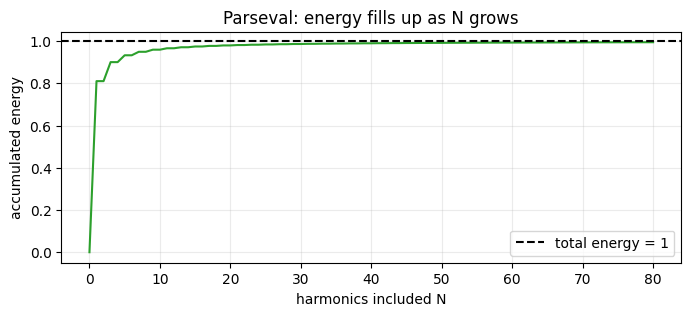

In [3]:
# Series energy accumulates to the total: (1/2)Σ b_n^2 -> mean(square^2) = 1.
square_2pi = lambda x: np.sign(np.sin(x))
a, b = transforms.trig_coeffs(square_2pi, n_max=80, period=2 * np.pi)
energy_cum = np.cumsum(0.5 * (a**2 + b**2))  # a[0] handled below
energy_cum += (a[0] / 2) ** 2                 # DC term (0 here)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(len(energy_cum)), energy_cum, color="#2ca02c")
ax.axhline(1.0, color="black", ls="--", label="total energy = 1")
ax.set_xlabel("harmonics included N"); ax.set_ylabel("accumulated energy")
ax.set_title("Parseval: energy fills up as N grows"); ax.legend(); ax.grid(alpha=.25)
plt.show()

### エネルギーは少数の倍音に集中する

各倍音のエネルギー $\tfrac12(a_n^2+b_n^2)$ と、その累積が全エネルギー(=1)へ達する様子(Parseval)。

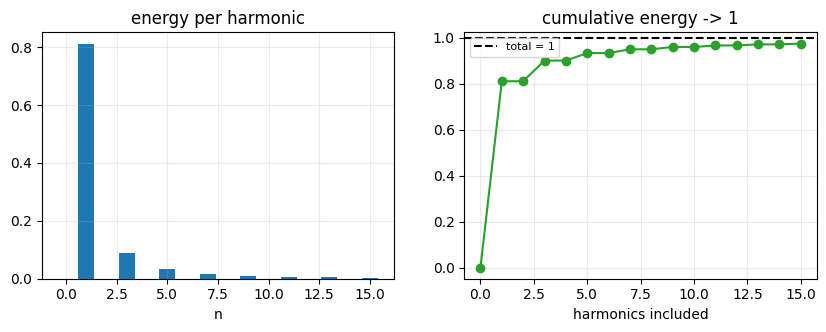

In [4]:
# Energy per harmonic and its cumulative sum reaching the total (Parseval).
sq = lambda x: np.sign(np.sin(x))
a, b = transforms.trig_coeffs(sq, n_max=15, period=2 * np.pi)
e = 0.5 * (a**2 + b**2)
e[0] = (a[0] / 2) ** 2
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(np.arange(len(e)), e, color="#1f77b4")
ax[0].set_title("energy per harmonic"); ax[0].set_xlabel("n")
ax[1].plot(np.arange(len(e)), np.cumsum(e), "o-", color="#2ca02c")
ax[1].axhline(1.0, color="black", ls="--", label="total = 1")
ax[1].set_title("cumulative energy -> 1"); ax[1].set_xlabel("harmonics included"); ax[1].legend(fontsize=8)
for a_ in ax:
    a_.grid(alpha=0.25)
plt.show()

## Invariant / Energy — 平均二乗誤差は単調に減る

部分和の次数 $N$ を上げると、平均二乗誤差は **単調に減少して 0** に向かいます
(L² 収束)。これは「エネルギーの意味では確かに収束する」ことを示します。

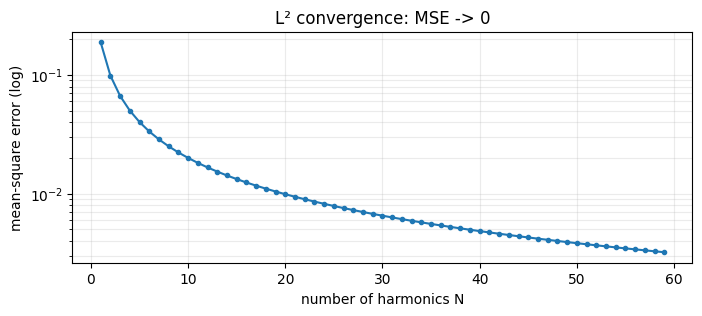

In [5]:
# Mean-square error of the square-wave partial sums decreases to 0.
t, _ = signals.time_grid(1.0, 4000.0)
target = signals.square_wave(t, 3.0)
Ns = np.arange(1, 60)
mse = [np.mean((signals.square_wave_partial_sum(t, 3.0, k) - target) ** 2) for k in Ns]

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(Ns, mse, "o-", ms=3, color="#1f77b4")
ax.set_xlabel("number of harmonics N"); ax.set_ylabel("mean-square error (log)")
ax.set_title("L² convergence: MSE -> 0"); ax.grid(alpha=.25, which="both")
plt.show()

## 滑らかさ ↔ 係数減衰(本章の主役)

**関数が滑らかなほど、高周波成分が速く小さくなります。**

- 不連続(矩形波): $|c_n|\sim 1/n$
- 連続だが折れ点あり(三角波): $|c_n|\sim 1/n^2$
- 無限回微分可能($e^{\sin x}$): $|c_n|$ は **指数的**に減衰

一般に「$k$ 回連続微分可能なら $|c_n| = O(1/n^{k+1})$」。
これは後で「滑らかな信号はローパスで失うものが少ない=圧縮しやすい」に直結します。

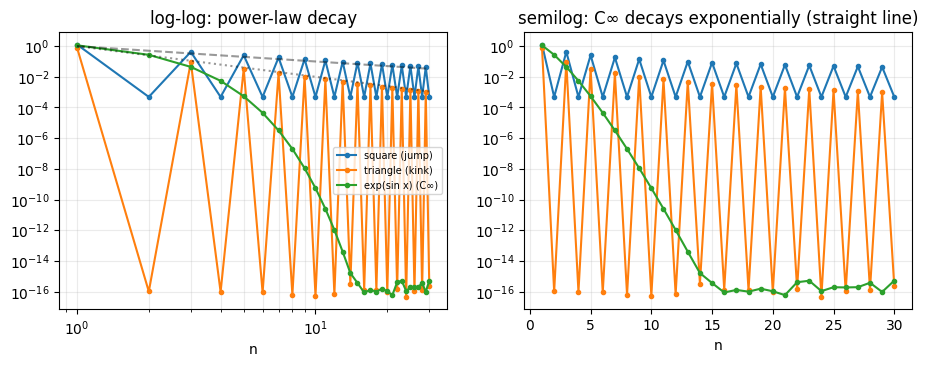

In [6]:
# Decay rate encodes smoothness. Left: power laws (log-log). Right: exponential (semilog).
period = 2 * np.pi
funcs = {
    "square (jump)":     lambda x: signals.square_wave(x, 1 / period),
    "triangle (kink)":   lambda x: signals.triangle_wave(x, 1 / period),
    "exp(sin x) (C∞)":   lambda x: np.exp(np.sin(x)),
}
n_max = 30
ns = np.arange(1, n_max + 1)
mags = {}
for name, f in funcs.items():
    a, b = transforms.trig_coeffs(f, n_max=n_max, period=period)
    mags[name] = np.hypot(a[1:], b[1:])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name, m in mags.items():
    ax[0].loglog(ns, m + 1e-18, "o-", ms=3, label=name)
ax[0].loglog(ns, 1 / ns, "k--", alpha=.4); ax[0].loglog(ns, 1 / ns**2, "k:", alpha=.4)
ax[0].set_title("log-log: power-law decay"); ax[0].set_xlabel("n"); ax[0].legend(fontsize=7)
ax[0].grid(alpha=.25, which="both")
for name, m in mags.items():
    ax[1].semilogy(ns, m + 1e-18, "o-", ms=3, label=name)
ax[1].set_title("semilog: C∞ decays exponentially (straight line)")
ax[1].set_xlabel("n"); ax[1].grid(alpha=.25, which="both")
plt.show()

## Failure Mode — Gibbs は sup ノルムでは消えない

MSE は 0 に向かうのに、**最大誤差は 0 に向かいません**。不連続の近くの overshoot 比は
$N$ を増やしても $\approx 0.0895$(ジャンプ高さ 2 に対して片側 0.0895)に張り付きます。
「収束した」と言うときは、どのノルムでの話かを必ず意識してください。

In [7]:
# Sup-norm error stays ~0.0895 even as MSE -> 0.
t, _ = signals.time_grid(1.0, 16000.0)
target = signals.square_wave(t, 3.0)
print(f"{'N':>5} {'MSE':>12} {'max error':>12}")
for N in [10, 40, 160, 640]:
    approx = signals.square_wave_partial_sum(t, 3.0, N)
    print(f"{N:5d} {np.mean((approx - target) ** 2):12.2e} {np.max(np.abs(approx - target)):12.4f}")

    N          MSE    max error
   10     2.02e-02       1.0000
   40     5.00e-03       1.0000
  160     1.21e-03       1.0000
  640     2.67e-04       1.0000


## Application — エネルギー圧縮と圧縮の予感

Parseval により「少数の大きな係数」が全エネルギーの大半を担うなら、
残りを捨てても誤差(エネルギー)は小さい。これが JPEG など **変換符号化** の原理で、
09 章の画像圧縮につながります。

## Exercises

1. **Basel 問題**: 矩形波の Parseval から $\sum_{n\ \text{odd}} 1/n^2 = \pi^2/8$ を導け。
2. **三角波のエネルギー**: 三角波で Parseval を数値確認し、累積エネルギー図を描け。
3. **収束の意味**: ある $N$ で「MSE は小さいが max error は大きい」例を作り、図で示せ。
4. **滑らかさ**: $f(x)=|\sin x|$ の係数減衰の次数を測り、滑らかさ($C^0$ で折れ点)と整合するか調べよ。

## Advanced Notes

```{admonition} 収束の階層と完備性
:class: note
$L^2$ では Riesz–Fischer により部分和は常に $L^2$ 収束する(基底が完備だから)。
各点収束はより繊細で、連続関数ですら全点では収束しない例がある一方、
**Carleson の定理**(1966)は $L^2$ 関数のフーリエ級数が **ほとんど至るところ**
各点収束することを保証する。一様収束は $f$ が連続かつ有界変動などの追加条件を要する。
```

- Bessel の不等式 $\sum|c_n|^2 \le \frac{1}{2\pi}\int|f|^2$ は任意の正規直交系で成立、
  等号(Parseval)は系が **完備** なときに限る。
- 係数減衰 ↔ 滑らかさは双対的(時間の滑らかさ = 周波数の速い減衰)で、04 章の
  不確定性原理と同じ精神。